# Process the AGAP airborne magnetic data

We try to recreate the BAS processing steps, as outlined here: https://data.bas.ac.uk/full-record.php?id=GB/NERC/BAS/PDC/01308

In [21]:
# %load_ext autoreload
# %autoreload 2

import cmocean
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import verde as vd

import airbornegeo

## Load data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is download and subset in the notebook `AGAP_magnetic_survey`.

In [2]:
data_df = pd.read_csv("data/AGAP_magnetic_survey.csv")

data_df = data_df[
    [
        "Lon",
        "Lat",
        "Height_WGS1984",
        "Date",
        "Time",
        "unixtime",
        "easting",
        "northing",
        "line_name",
        "line",
        "MagR",  # raw magnetic field intensity
        "MagC",  # compensated or low pass filtered (some dummies)
        "RefField",  # IGRF intensity
        # 'TCorr', # Tip tanks?
        "MagRTC",  # TFA
        "BCorr_AGAP_N",  # 60 min low pass filter magnetic base station
        "BCorr_AGAP_NS",
        "BCorr_AGAP_S",
        "BCorr_AGAP_SP",
        "BCorr_Applied",  # combined base stations
        "MagBRTC",  # MagRTC - Bcorr_Applied
        "ACorr",  # heading error correction
        "SCorr",  # ?
        "MagF",  # final TFA before levelling
        "MagL",  # cross-over levelled
        "MagML",  # microlevelled
    ]
]

print(data_df.columns)
data_df.head()

Index(['Lon', 'Lat', 'Height_WGS1984', 'Date', 'Time', 'unixtime', 'easting',
       'northing', 'line_name', 'line', 'MagR', 'MagC', 'RefField', 'MagRTC',
       'BCorr_AGAP_N', 'BCorr_AGAP_NS', 'BCorr_AGAP_S', 'BCorr_AGAP_SP',
       'BCorr_Applied', 'MagBRTC', 'ACorr', 'SCorr', 'MagF', 'MagL', 'MagML'],
      dtype='str')


,Lon,Lat,Height_WGS1984,Date,Time,unixtime,easting,northing,line_name,line,...,BCorr_AGAP_NS,BCorr_AGAP_S,BCorr_AGAP_SP,BCorr_Applied,MagBRTC,ACorr,SCorr,MagF,MagL,MagML
0,75.635600,-84.104393,4109.4,2008-12-17,0 days 07:53:42,1.229500e+09,621072.177354,159052.962392,DA500_11.0,1,...,NaN,NaN,18.04,-18.04,-8.00,8.32,-32.96,-32.96,-22.30,NaN
1,75.636138,-84.103897,4111.5,2008-12-17,0 days 07:53:43,1.229500e+09,621126.010622,159060.533993,DA500_11.0,1,...,NaN,NaN,18.01,-18.01,-8.82,7.47,-33.81,-33.81,-23.06,NaN
2,75.636699,-84.103403,4113.6,2008-12-17,0 days 07:53:44,1.229500e+09,621179.696916,159067.801202,DA500_11.0,1,...,NaN,NaN,17.98,-17.98,-9.66,6.60,-34.68,-34.68,-23.81,NaN
3,75.637282,-84.102910,4115.4,2008-12-17,0 days 07:53:45,1.229500e+09,621233.338990,159074.801823,DA500_11.0,1,...,NaN,NaN,17.95,-17.95,-10.51,5.72,-35.56,-35.56,-24.57,NaN
4,75.637876,-84.102417,4117.1,2008-12-17,0 days 07:53:46,1.229500e+09,621287.011834,159081.682095,DA500_11.0,1,...,NaN,NaN,17.92,-17.92,-11.36,4.84,-36.44,-36.44,-25.32,NaN


In [3]:
# turn to geopandas geodataframe
data_df = gpd.GeoDataFrame(
    data_df,
    geometry=gpd.points_from_xy(x=data_df.easting, y=data_df.northing),
    crs="EPSG:3031",
)

## Distance along line

In [4]:
data_df["distance_along_line"] = airbornegeo.along_track_distance(
    data_df,
    groupby_column="line",
)
data_df.head()

,Lon,Lat,Height_WGS1984,Date,Time,unixtime,easting,northing,line_name,line,...,BCorr_AGAP_SP,BCorr_Applied,MagBRTC,ACorr,SCorr,MagF,MagL,MagML,geometry,distance_along_line
0,75.635600,-84.104393,4109.4,2008-12-17,0 days 07:53:42,1.229500e+09,621072.177354,159052.962392,DA500_11.0,1,...,18.04,-18.04,-8.00,8.32,-32.96,-32.96,-22.30,NaN,POINT (621072.177 159052.962),0.000000
1,75.636138,-84.103897,4111.5,2008-12-17,0 days 07:53:43,1.229500e+09,621126.010622,159060.533993,DA500_11.0,1,...,18.01,-18.01,-8.82,7.47,-33.81,-33.81,-23.06,NaN,POINT (621126.011 159060.534),54.363130
2,75.636699,-84.103403,4113.6,2008-12-17,0 days 07:53:44,1.229500e+09,621179.696916,159067.801202,DA500_11.0,1,...,17.98,-17.98,-9.66,6.60,-34.68,-34.68,-23.81,NaN,POINT (621179.697 159067.801),108.539052
3,75.637282,-84.102910,4115.4,2008-12-17,0 days 07:53:45,1.229500e+09,621233.338990,159074.801823,DA500_11.0,1,...,17.95,-17.95,-10.51,5.72,-35.56,-35.56,-24.57,NaN,POINT (621233.339 159074.802),162.636009
4,75.637876,-84.102417,4117.1,2008-12-17,0 days 07:53:46,1.229500e+09,621287.011834,159081.682095,DA500_11.0,1,...,17.92,-17.92,-11.36,4.84,-36.44,-36.44,-25.32,NaN,POINT (621287.012 159081.682),216.748044


## IGRF correction

Number of segments: 13


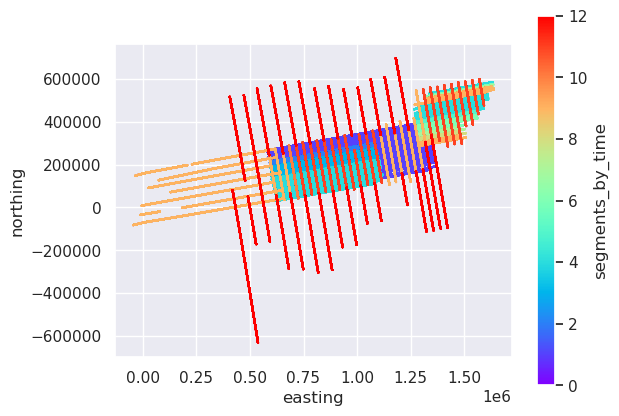

In [5]:
# make a datetime column
data_df["datetime"] = data_df.Date + " " + data_df.Time.str.split("days ").str.get(1)

# make segments where there are > 6 hr gaps in time
data_df["segments_by_time"] = airbornegeo.split_into_segments(
    data_df,
    column_name="unixtime",
    threshold=60 * 60 * 60 * 6,  # 6 hrs
)
print(f"Number of segments: {len(data_df.segments_by_time.unique())}")

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="segments_by_time",
    s=0.2,
    cmap="rainbow",
)
ax.set_aspect("equal")

In [6]:
intensity, inc, dec = airbornegeo.igrf(
    data_df,
    datetime_column="datetime",
    latitude_column="Lat",
    longitude_column="Lon",
    height_column="Height_WGS1984",
    groupby_column="segments_by_time",
)
data_df["IGRF_intensity"] = intensity

data_df["mag_IGRF_corrected"] = data_df.MagC - data_df.IGRF_intensity

data_df.head()

Segments: 100%|██████████| 13/13 [00:07<00:00,  1.67it/s]


,Lon,Lat,Height_WGS1984,Date,Time,unixtime,easting,northing,line_name,line,...,SCorr,MagF,MagL,MagML,geometry,distance_along_line,datetime,segments_by_time,IGRF_intensity,mag_IGRF_corrected
0,75.635600,-84.104393,4109.4,2008-12-17,0 days 07:53:42,1.229500e+09,621072.177354,159052.962392,DA500_11.0,1,...,-32.96,-32.96,-22.30,NaN,POINT (621072.177 159052.962),0.000000,2008-12-17 07:53:42,0,55085.052201,58.047799
1,75.636138,-84.103897,4111.5,2008-12-17,0 days 07:53:43,1.229500e+09,621126.010622,159060.533993,DA500_11.0,1,...,-33.81,-33.81,-23.06,NaN,POINT (621126.011 159060.534),54.363130,2008-12-17 07:53:43,0,55085.014585,57.185415
2,75.636699,-84.103403,4113.6,2008-12-17,0 days 07:53:44,1.229500e+09,621179.696916,159067.801202,DA500_11.0,1,...,-34.68,-34.68,-23.81,NaN,POINT (621179.697 159067.801),108.539052,2008-12-17 07:53:44,0,55084.979022,56.320978
3,75.637282,-84.102910,4115.4,2008-12-17,0 days 07:53:45,1.229500e+09,621233.338990,159074.801823,DA500_11.0,1,...,-35.56,-35.56,-24.57,NaN,POINT (621233.339 159074.802),162.636009,2008-12-17 07:53:45,0,55084.953265,55.436735
4,75.637876,-84.102417,4117.1,2008-12-17,0 days 07:53:46,1.229500e+09,621287.011834,159081.682095,DA500_11.0,1,...,-36.44,-36.44,-25.32,NaN,POINT (621287.012 159081.682),216.748044,2008-12-17 07:53:46,0,55084.931072,54.548928


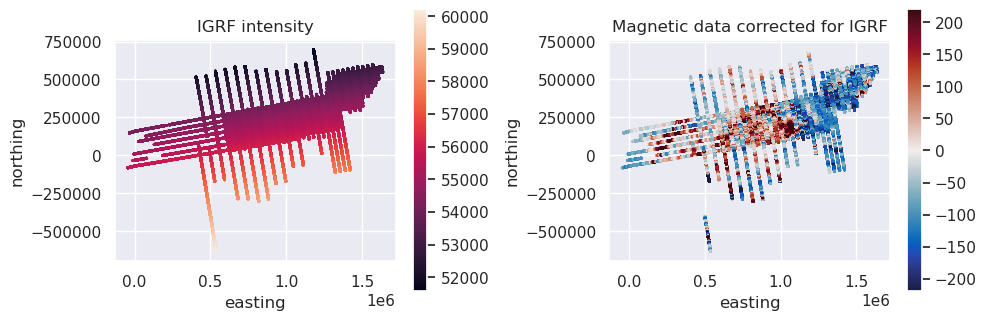

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="IGRF_intensity",
    s=1,
    ax=axs[0],
    colorbar=False,
    title="IGRF intensity",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

maxabs = vd.maxabs(data_df.mag_IGRF_corrected, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="mag_IGRF_corrected",
    s=1,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    ax=axs[1],
    colorbar=False,
    title="Magnetic data corrected for IGRF",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

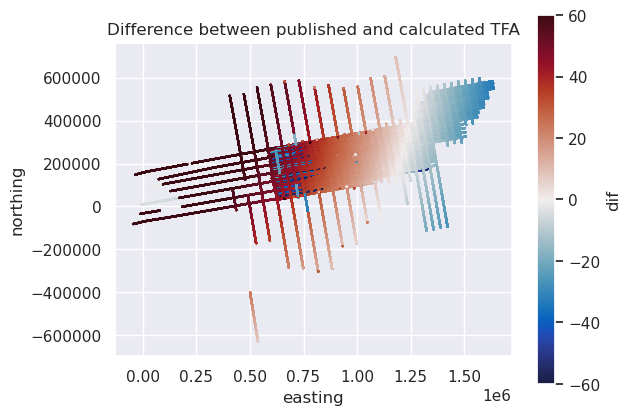

In [9]:
# compare the published TFA with the one calculated here
data_df["dif"] = data_df.mag_IGRF_corrected - data_df.MagRTC

maxabs = vd.maxabs(data_df.dif, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="dif",
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    s=0.2,
    title="Difference between published and calculated TFA",
)
ax.set_aspect("equal")

In [10]:
# for now just use their values
data_df = data_df.drop(columns=["mag_IGRF_corrected"], errors="ignore")
data_df["mag_IGRF_corrected"] = data_df.MagRTC

## Diurnal correction

In [11]:
data_df["mag_diurnal_corrected"] = data_df.mag_IGRF_corrected - data_df.BCorr_Applied
data_df.head()

,Lon,Lat,Height_WGS1984,Date,Time,unixtime,easting,northing,line_name,line,...,MagL,MagML,geometry,distance_along_line,datetime,segments_by_time,IGRF_intensity,dif,mag_IGRF_corrected,mag_diurnal_corrected
0,75.635600,-84.104393,4109.4,2008-12-17,0 days 07:53:42,1.229500e+09,621072.177354,159052.962392,DA500_11.0,1,...,-22.30,NaN,POINT (621072.177 159052.962),0.000000,2008-12-17 07:53:42,0,55085.052201,48.007799,10.04,28.08
1,75.636138,-84.103897,4111.5,2008-12-17,0 days 07:53:43,1.229500e+09,621126.010622,159060.533993,DA500_11.0,1,...,-23.06,NaN,POINT (621126.011 159060.534),54.363130,2008-12-17 07:53:43,0,55085.014585,47.995415,9.19,27.20
2,75.636699,-84.103403,4113.6,2008-12-17,0 days 07:53:44,1.229500e+09,621179.696916,159067.801202,DA500_11.0,1,...,-23.81,NaN,POINT (621179.697 159067.801),108.539052,2008-12-17 07:53:44,0,55084.979022,48.000978,8.32,26.30
3,75.637282,-84.102910,4115.4,2008-12-17,0 days 07:53:45,1.229500e+09,621233.338990,159074.801823,DA500_11.0,1,...,-24.57,NaN,POINT (621233.339 159074.802),162.636009,2008-12-17 07:53:45,0,55084.953265,47.996735,7.44,25.39
4,75.637876,-84.102417,4117.1,2008-12-17,0 days 07:53:46,1.229500e+09,621287.011834,159081.682095,DA500_11.0,1,...,-25.32,NaN,POINT (621287.012 159081.682),216.748044,2008-12-17 07:53:46,0,55084.931072,47.988928,6.56,24.48


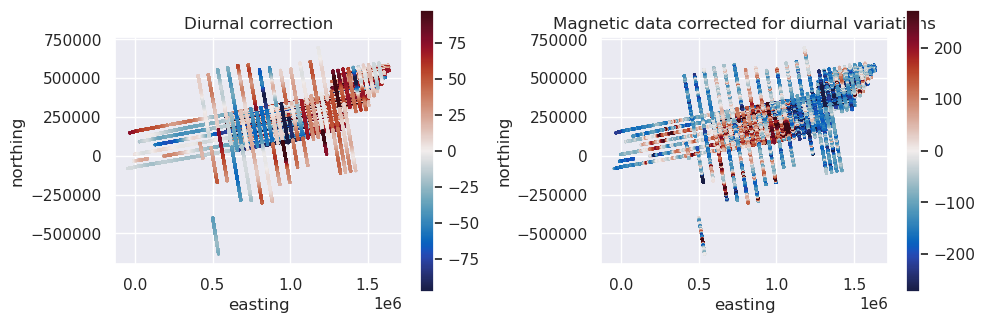

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

maxabs = vd.maxabs(data_df.BCorr_Applied, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="BCorr_Applied",
    s=1,
    ax=axs[0],
    colorbar=False,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    title="Diurnal correction",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

maxabs = vd.maxabs(data_df.mag_diurnal_corrected, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="mag_diurnal_corrected",
    s=1,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    ax=axs[1],
    colorbar=False,
    title="Magnetic data corrected for diurnal variations",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

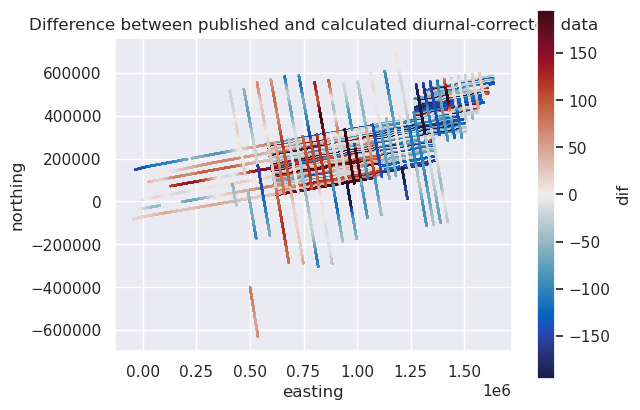

In [13]:
# compare the published TFA with the one calculated here
data_df["dif"] = data_df.mag_diurnal_corrected - data_df.MagBRTC

maxabs = vd.maxabs(data_df.dif, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="dif",
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    s=0.2,
    title="Difference between published and calculated diurnal-corrected data",
)
ax.set_aspect("equal")

In [14]:
# for now just use their values
data_df = data_df.drop(columns=["mag_diurnal_corrected"], errors="ignore")
data_df["mag_diurnal_corrected"] = data_df.MagBRTC

## Final data

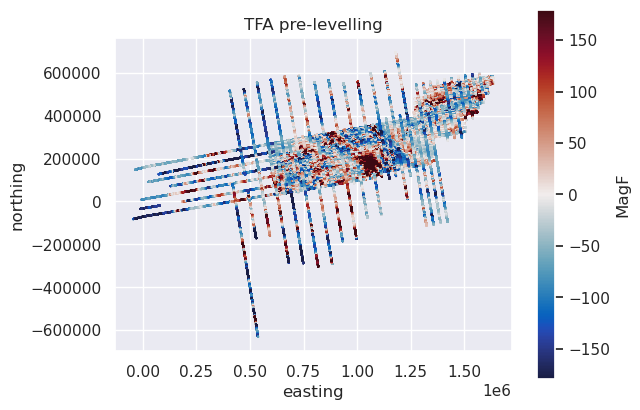

In [15]:
maxabs = vd.maxabs(data_df.MagF, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="MagF",
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    s=0.2,
    title="TFA pre-levelling",
)
ax.set_aspect("equal")

## Save csv

In [16]:
# save to csv for further levelling notebook
# eventually will use our version, but for checking the levelling is working correctly,
# we will just use their version
df = data_df

df = df[
    [
        "line",
        "easting",
        "northing",
        "Lon",
        "Lat",
        "Height_WGS1984",
        "unixtime",
        "distance_along_line",
        "MagF",
        "MagL",
        "MagML",
    ]
]

df = df.rename(
    columns={
        "MagF": "mag",
        "MagL": "mag_levelled",
        "MagML": "mag_microlevelled",
        "Lon": "longitude",
        "Lat": "latitude",
        "Height_WGS1984": "height",
    }
)
df = df.reset_index(drop=True)

df

,line,easting,northing,longitude,latitude,height,unixtime,distance_along_line,mag,mag_levelled,mag_microlevelled
0,1,6.210722e+05,159052.962392,75.635600,-84.104393,4109.4,1.229500e+09,0.000000,-32.96,-22.30,NaN
1,1,6.211260e+05,159060.533993,75.636138,-84.103897,4111.5,1.229500e+09,54.363130,-33.81,-23.06,NaN
2,1,6.211797e+05,159067.801202,75.636699,-84.103403,4113.6,1.229500e+09,108.539052,-34.68,-23.81,NaN
3,1,6.212333e+05,159074.801823,75.637282,-84.102910,4115.4,1.229500e+09,162.636009,-35.56,-24.57,NaN
4,1,6.212870e+05,159081.682095,75.637876,-84.102417,4117.1,1.229500e+09,216.748044,-36.44,-25.32,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1060384,206,1.082042e+06,113004.019427,84.037875,-80.011449,4193.4,1.231249e+09,178373.722649,-45.20,-49.77,NaN
1060385,206,1.082042e+06,113004.019427,84.037875,-80.011449,4193.4,1.231249e+09,178373.722649,-45.67,-50.20,NaN
1060386,206,1.082042e+06,113004.019427,84.037875,-80.011449,4193.4,1.231249e+09,178373.722649,-46.10,-50.67,NaN
1060387,206,1.082042e+06,113004.019427,84.037875,-80.011449,4193.4,1.231249e+09,178373.722649,-46.50,-51.10,NaN


In [17]:
df.to_csv("data/AGAP_magnetic_survey_processed.csv", index=False)

In [18]:
airbornegeo.plotly_points(
    df[::10],
    color_col="mag_microlevelled",
    size=3,
)

In [19]:
airbornegeo.plotly_points(
    df[::10],
    color_col="mag_levelled",
    size=3,
)

In [22]:
# block reduce by line to speed up the notebook
df_blocked = airbornegeo.block_reduce(
    df,
    np.median,
    spacing=200,
    reduce_by="distance_along_line",
    groupby_column="line",
)
df_blocked

Segments: 100%|██████████| 206/206 [04:59<00:00,  1.46s/it]


,distance_along_line,easting,northing,longitude,latitude,height,unixtime,mag,mag_levelled,mag_microlevelled,line
0,81.451091,6.211529e+05,159064.167598,75.636418,-84.103650,4112.55,1.229500e+09,-34.245,-23.435,NaN,1
1,297.742539,6.213673e+05,159092.051982,75.638758,-84.101679,4119.45,1.229500e+09,-37.740,-26.450,NaN,1
2,512.819231,6.215803e+05,159122.206492,75.640867,-84.099716,4124.15,1.229500e+09,-40.975,-29.410,NaN,1
3,700.811387,6.217661e+05,159150.747140,75.642512,-84.097999,4127.50,1.229500e+09,-43.430,-31.940,NaN,1
4,861.711758,6.219250e+05,159176.326498,75.643816,-84.096528,4131.00,1.229500e+09,-45.300,-34.060,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
352090,177481.910664,1.082191e+06,112124.803785,84.084743,-80.010923,4191.10,1.231249e+09,-20.910,-25.410,NaN,206
352091,177671.458931,1.082160e+06,112311.745703,84.074781,-80.011032,4191.35,1.231249e+09,-23.525,-28.040,NaN,206
352092,177861.049986,1.082128e+06,112498.706874,84.064816,-80.011141,4191.50,1.231249e+09,-26.040,-30.540,NaN,206
352093,178088.659832,1.082090e+06,112723.160432,84.052853,-80.011272,4191.70,1.231249e+09,-28.960,-33.460,NaN,206


In [23]:
df_blocked.to_csv("data/AGAP_magnetic_survey_processed_blocked.csv", index=False)